In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Bidirectional, GRU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Load and preprocess data
df = pd.read_csv('generated_new.csv')
df.dropna(inplace=True)

# Feature Engineering
df['Minutes'] = pd.to_datetime(df['Time'], format='%H:%M', errors='coerce').dt.hour * 60 + \
                pd.to_datetime(df['Time'], format='%H:%M', errors='coerce').dt.minute
df['Hour'] = df['Minutes'] // 60
df['Is_Weekend'] = (pd.to_datetime(df['Time'], format='%H:%M').dt.weekday >= 5).astype(int)
df['Temp_Humidity'] = df['Temp'] * df['Humidity']
df['Light_Occupancy'] = df['Light_Intensity'] * df['Occupancy']
df['Temp_Light'] = df['Temp'] * df['Light_Intensity']
df['Temp_Occupancy'] = df['Temp'] * df['Occupancy']
df['Humidity_Light'] = df['Humidity'] * df['Light_Intensity']
df['Energy_Lag1'] = df['Energy'].shift(1)
df['Temp_Lag1'] = df['Temp'].shift(1)
df['Humidity_Lag1'] = df['Humidity'].shift(1)
df['Light_Lag1'] = df['Light_Intensity'].shift(1)
df['Occupancy_Lag1'] = df['Occupancy'].shift(1)
df['Energy_Lag2'] = df['Energy'].shift(2)
df['Temp_Lag2'] = df['Temp'].shift(2)
df['Humidity_Lag2'] = df['Humidity'].shift(2)
df['Temp_RollingMean3'] = df['Temp'].rolling(window=3).mean()
df['Humidity_RollingMean3'] = df['Humidity'].rolling(window=3).mean()
df['Light_RollingMean3'] = df['Light_Intensity'].rolling(window=3).mean()

df.dropna(inplace=True)
df = pd.get_dummies(df, columns=['Day'], drop_first=True)

# Define features and target
features = ['Minutes', 'Temp', 'Humidity', 'Light_Intensity', 'Occupancy', 'Temp_Humidity', 'Light_Occupancy',
            'Temp_Light', 'Temp_Occupancy', 'Humidity_Light', 'Is_Weekend', 'Energy_Lag1', 'Temp_Lag1', 'Humidity_Lag1',
            'Light_Lag1', 'Occupancy_Lag1', 'Energy_Lag2', 'Temp_Lag2', 'Humidity_Lag2',
            'Temp_RollingMean3', 'Humidity_RollingMean3', 'Light_RollingMean3'] + [col for col in df.columns if col.startswith('Day_')]

X = df[features].values
y = df['Energy'].values






In [2]:
# Scale data
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))

# Create sequences for LSTM
def create_sequences(X, y, seq_length):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i + seq_length])
        y_seq.append(y[i + seq_length])
    return np.array(X_seq), np.array(y_seq)

seq_length = 15
X_seq, y_seq = create_sequences(X_scaled, y_scaled, seq_length)


In [3]:

# Train/test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, random_state=42)

# Build the optimized LSTM model with GRU
def build_optimized_model(input_shape):
    model = Sequential([
        Bidirectional(GRU(128, activation='tanh', return_sequences=True), input_shape=input_shape),
        Dropout(0.3),
        BatchNormalization(),
        GRU(64, activation='tanh', return_sequences=False),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

model = build_optimized_model((seq_length, X_train.shape[2]))


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [4]:

# Use early stopping and learning rate reduction on plateau
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
lr_reduction = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stopping, lr_reduction],
    verbose=1
)

# Get predictions
y_pred_scaled = model.predict(X_test)
y_test_actual = scaler_y.inverse_transform(y_test.reshape(-1, 1))
y_pred_actual = scaler_y.inverse_transform(y_pred_scaled)

Epoch 1/200
240/240 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - loss: 0.0961 - mae: 0.2165 - val_loss: 0.0493 - val_mae: 0.1850 - learning_rate: 0.0010
Epoch 2/200
240/240 ━━━━━━━━━━━━━━━━━━━━ 13s 55ms/step - loss: 0.0166 - mae: 0.1002 - val_loss: 0.0087 - val_mae: 0.0747 - learning_rate: 0.0010
Epoch 3/200
240/240 ━━━━━━━━━━━━━━━━━━━━ 13s 55ms/step - loss: 0.0118 - mae: 0.0842 - val_loss: 0.0080 - val_mae: 0.0729 - learning_rate: 0.0010
Epoch 4/200
240/240 ━━━━━━━━━━━━━━━━━━━━ 13s 55ms/step - loss: 0.0114 - mae: 0.0829 - val_loss: 0.0090 - val_mae: 0.0811 - learning_rate: 0.0010
Epoch 5/200
240/240 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - loss: 0.0084 - mae: 0.0710 - val_loss: 0.0057 - val_mae: 0.0612 - learning_rate: 0.0010
Epoch 6/200
240/240 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - loss: 0.0079 - mae: 0.0686 - val_loss: 0.0049 - val_mae: 0.0569 - learning_rate: 0.0010
Epoch 7/200
240/240 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - loss: 0.0068 - mae: 0.0641 - val_loss: 0.0039 - val_mae: 0.0449 - learnin

In [5]:
# Evaluate metrics
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
mae = mean_absolute_error(y_test_actual, y_pred_actual)
r2 = r2_score(y_test_actual, y_pred_actual)
mape = np.mean(np.abs((y_test_actual - y_pred_actual) / y_test_actual)) * 100

print("\nModel Performance:")
print(f"Root Mean Square Error (RMSE): {rmse:.3f}")
print(f"Mean Absolute Error (MAE): {mae:.3f} kWh")
print(f"R-squared Score: {r2:.3f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")


Model Performance:
Root Mean Square Error (RMSE): 0.248
Mean Absolute Error (MAE): 0.182 kWh
R-squared Score: 0.989
Mean Absolute Percentage Error (MAPE): 2.60%


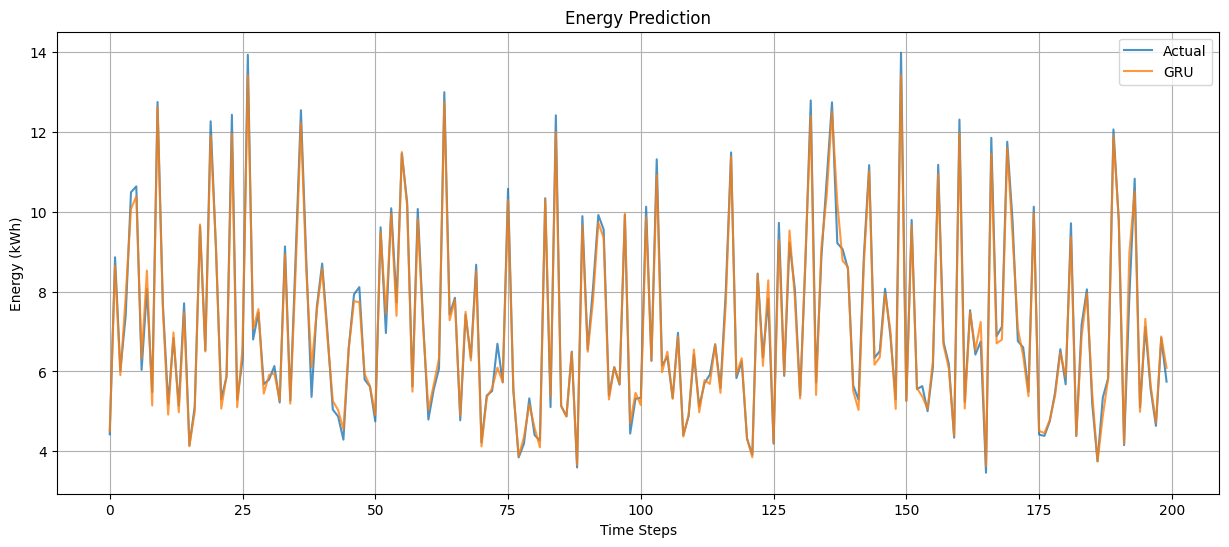

In [7]:

# Plot predictions
def plot_predictions(y_test_actual, y_pred_actual, num_points=200):
    plt.figure(figsize=(15, 6))
    plt.plot(y_test_actual[:num_points], label='Actual', alpha=0.8)
    plt.plot(y_pred_actual[:num_points], label='GRU', alpha=0.8)
    plt.title('Energy Prediction')
    plt.xlabel('Time Steps')
    plt.ylabel('Energy (kWh)')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_predictions(y_test_actual, y_pred_actual)
